#  Hospital Readmission Risk Analytics
## Notebook 2: Logistic Regression Baseline
### Diabetes 130-US Hospitals Dataset

---

### 📌 Why Start With Logistic Regression?

Before deploying complex models, we establish a **baseline**:
- **Interpretable** — each coefficient is a log-odds of readmission risk
- **Calibrated probabilities** — ideal for clinical risk scoring
- **Fast to train** — validates the pipeline before complex models
- **Performance floor** — any advanced model must beat this

**The logistic model:**
$$P(\text{readmit}=1 | X) = \frac{1}{1 + e^{-(\beta_0 + \sum_{j} \beta_j X_j)}}$$

A coefficient $\beta_j > 0$ means feature $X_j$ **increases** readmission probability.

---

### 📋 Notebook Goals
1. Stratified train/test split
2. Handle class imbalance with `class_weight='balanced'`
3. Evaluate: **AUC-ROC, precision, recall, F1, confusion matrix**
4. Interpret coefficients as **odds ratios**
5. Plot **ROC** and **precision-recall** curves

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

# ── Load prepared data from Notebook 1 ───────────────────────────────────────
df       = pd.read_csv("../Data/Processed Data/readmission_model_data.csv")
features = pd.read_csv("../Data/Processed Data/feature_list.csv")["feature"].tolist()
X        = df[features]
y        = df["readmit_30"]

print(f"✅ Data loaded: {X.shape[0]:,} samples, {X.shape[1]} features")
print(f"   Positive class rate: {y.mean()*100:.1f}%")

✅ Data loaded: 69,997 samples, 31 features
   Positive class rate: 9.0%


---
## 1. Train / Test Split

In [2]:
# Stratified 80/20 split — preserves class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training   : {X_train.shape[0]:>6,} samples  |  Positive: {y_train.mean()*100:.1f}%")
print(f"Test       : {X_test.shape[0]:>6,} samples  |  Positive: {y_test.mean()*100:.1f}%")

# Scale features — critical for Logistic Regression convergence & coefficient comparability
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

# Persist split for reuse in NB3 & NB4 (same split = fair model comparison)
with open("../Outputs/Models/train_test_split.pkl", "wb") as f:
    pickle.dump((X_train, X_test, y_train, y_test), f)
with open("../Outputs/Models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("\n✅ Saved train/test split + scaler for NB3 & NB4")

Training   : 55,997 samples  |  Positive: 9.0%
Test       : 14,000 samples  |  Positive: 9.0%

✅ Saved train/test split + scaler for NB3 & NB4


---
## 2. Train Logistic Regression

In [3]:
lr = LogisticRegression(
    max_iter   = 1000,
    class_weight = "balanced",  # upweights minority class proportionally
    C          = 1.0,           # inverse regularisation strength (L2)
    solver     = "lbfgs",
    random_state = 42
)
lr.fit(X_train_sc, y_train)

print("✅ Logistic Regression trained")
print(f"   Iterations to converge : {lr.n_iter_[0]}")

# 5-Fold cross-validated AUC on training data
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"\n5-Fold CV AUC : {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")

✅ Logistic Regression trained
   Iterations to converge : 16

5-Fold CV AUC : 0.6232 ± 0.0141


---
## 3. Test Set Evaluation

In [4]:
y_prob = lr.predict_proba(X_test_sc)[:, 1]
y_pred = lr.predict(X_test_sc)

auc = roc_auc_score(y_test, y_prob)
ap  = average_precision_score(y_test, y_prob)

print("=" * 55)
print("LOGISTIC REGRESSION — TEST SET PERFORMANCE")
print("=" * 55)
print(f"  AUC-ROC                    : {auc:.4f}")
print(f"  Average Precision (PR-AUC) : {ap:.4f}")
print()
print(classification_report(
    y_test, y_pred,
    target_names=["Not Readmitted", "Readmitted <30"]
))

LOGISTIC REGRESSION — TEST SET PERFORMANCE
  AUC-ROC                    : 0.6289
  Average Precision (PR-AUC) : 0.1552

                precision    recall  f1-score   support

Not Readmitted       0.93      0.64      0.76     12743
Readmitted <30       0.13      0.53      0.21      1257

      accuracy                           0.63     14000
     macro avg       0.53      0.59      0.48     14000
  weighted avg       0.86      0.63      0.71     14000




 ROC Curve Plot saved to outputs/figures/

 Precision-Recall Curve Plot saved to outputs/figures/

 Confusion Matrix Plot saved to outputs/figures/


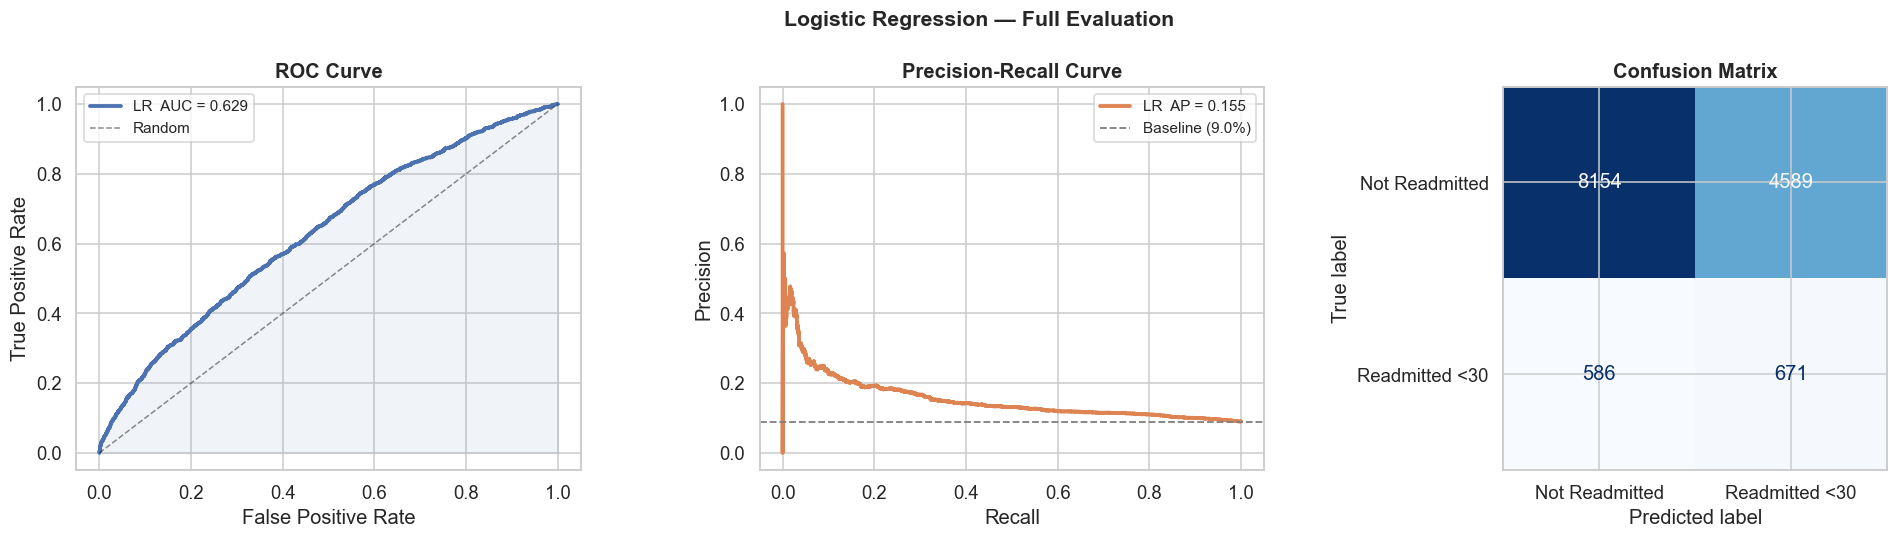


 Logistic Regression — Full Evaluation Plot saved to outputs/figures/


<Figure size 704x528 with 0 Axes>

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#  ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color="#4C72B0", lw=2.5, label=f"LR  AUC = {auc:.3f}")
axes[0].plot([0,1],[0,1], "k--", lw=1, alpha=0.5, label="Random")
axes[0].fill_between(fpr, tpr, alpha=0.08, color="#4C72B0")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", fontweight="bold")
axes[0].legend(fontsize=10)
plt.savefig(
    "Outputs/figures/ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n ROC Curve Plot saved to outputs/figures/")
#  Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, color="#DD8452", lw=2.5, label=f"LR  AP = {ap:.3f}")
axes[1].axhline(y_test.mean(), color="grey", linestyle="--", lw=1.2,
                label=f"Baseline ({y_test.mean()*100:.1f}%)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve", fontweight="bold")
axes[1].legend(fontsize=10)
plt.savefig(
    "Outputs/figures/Precision-Recall_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n Precision-Recall Curve Plot saved to outputs/figures/")
#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Readmitted", "Readmitted <30"]).plot(
    ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title("Confusion Matrix", fontweight="bold")

plt.savefig(
    "Outputs/figures/Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n Confusion Matrix Plot saved to outputs/figures/")
plt.suptitle("Logistic Regression — Full Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

plt.savefig(
    "Outputs/figures/Logistic_Regression.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n Logistic Regression — Full Evaluation Plot saved to outputs/figures/")

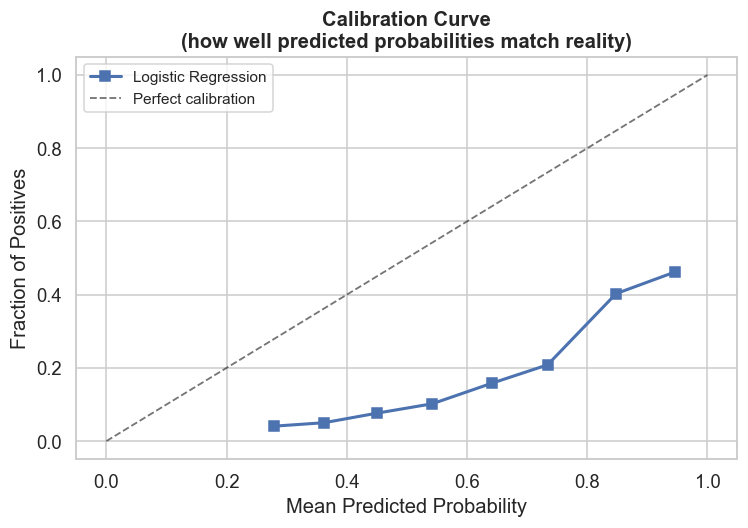

 A well-calibrated model is essential for clinical risk communication.
   If the curve hugs the diagonal, the model's probabilities can be trusted.


In [7]:
#  Calibration curve
# Shows whether predicted probabilities match actual event rates
frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mean_pred, frac_pos, "s-", color="#4C72B0", lw=2, label="Logistic Regression")
ax.plot([0,1],[0,1], "k--", lw=1.2, alpha=0.6, label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curve\n(how well predicted probabilities match reality)",
             fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

plt.savefig(
    "Outputs/figures/how_well_predicted_probabilities_match_reality.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n Calibration Curve Plot saved to outputs/figures/")
print(" A well-calibrated model is essential for clinical risk communication.")
print("   If the curve hugs the diagonal, the model's probabilities can be trusted.")

---
## 4. Coefficient Interpretation (Odds Ratios)

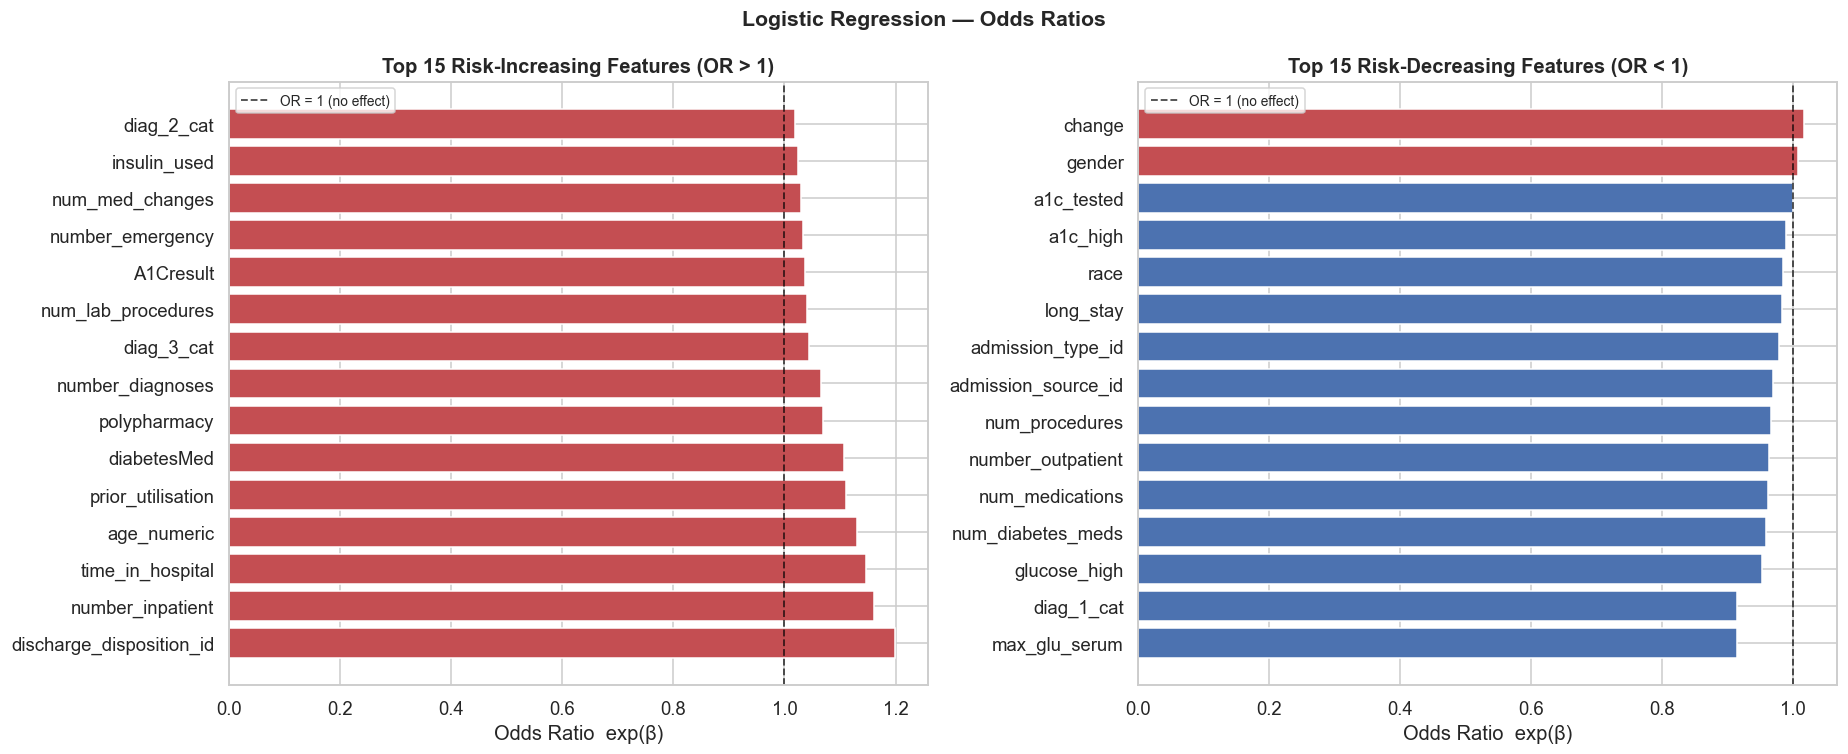


 Logistic Regression — Odds Ratios Plot saved to outputs/figures/
How to read Odds Ratios:
  OR > 1 → feature increases readmission odds
  OR < 1 → feature decreases readmission odds
  OR = 1 → feature has no effect

                 feature  coefficient  odds_ratio
discharge_disposition_id       0.1810      1.1984
        number_inpatient       0.1493      1.1611
        time_in_hospital       0.1366      1.1463
             age_numeric       0.1230      1.1308
       prior_utilisation       0.1046      1.1102
             diabetesMed       0.1021      1.1075
            polypharmacy       0.0663      1.0686
        number_diagnoses       0.0637      1.0658
              diag_3_cat       0.0428      1.0437
      num_lab_procedures       0.0396      1.0404


<Figure size 704x528 with 0 Axes>

In [10]:
# Exponentiate coefficients → Odds Ratios
coef_df = pd.DataFrame({
    "feature"     : features,
    "coefficient" : lr.coef_[0],
    "odds_ratio"  : np.exp(lr.coef_[0])
}).sort_values("odds_ratio", ascending=False)

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for ax, subset, title in [
    (axes[0], coef_df.head(top_n), f"Top {top_n} Risk-Increasing Features (OR > 1)"),
    (axes[1], coef_df.tail(top_n).iloc[::-1], f"Top {top_n} Risk-Decreasing Features (OR < 1)"),
]:
    colors = ["#C44E52" if v > 1 else "#4C72B0" for v in subset["odds_ratio"]]
    ax.barh(subset["feature"], subset["odds_ratio"], color=colors, edgecolor="white")
    ax.axvline(1.0, color="black", linestyle="--", lw=1.2, alpha=0.7, label="OR = 1 (no effect)")
    ax.set_xlabel("Odds Ratio  exp(β)")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Logistic Regression — Odds Ratios", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

plt.savefig(
    "Outputs/figures/Logistic_Regression_Odds Ratios.png",
    dpi=300,
    bbox_inches="tight"
)

print("\n Logistic Regression — Odds Ratios Plot saved to outputs/figures/")

print("How to read Odds Ratios:")
print("  OR > 1 → feature increases readmission odds")
print("  OR < 1 → feature decreases readmission odds")
print("  OR = 1 → feature has no effect")
print()
print(coef_df[["feature","coefficient","odds_ratio"]].head(10).round(4).to_string(index=False))

In [9]:
# Save model results
with open("../Outputs/Models/lr_model.pkl", "wb") as f:
    pickle.dump(lr, f)

results = pd.DataFrame([{
    "Model"           : "Logistic Regression",
    "AUC_ROC"         : round(auc, 4),
    "Avg_Precision"   : round(ap, 4),
    "CV_AUC_Mean"     : round(cv_aucs.mean(), 4),
    "CV_AUC_Std"      : round(cv_aucs.std(), 4),
    "Precision_class1": round(precision_score(y_test, y_pred), 4),
    "Recall_class1"   : round(recall_score(y_test, y_pred), 4),
    "F1_class1"       : round(f1_score(y_test, y_pred), 4),
}])
results.to_csv("model_results.csv", index=False)
print("✅ Saved: lr_model.pkl, model_results.csv")
print(results.T.to_string())

✅ Saved: lr_model.pkl, model_results.csv
                                    0
Model             Logistic Regression
AUC_ROC                        0.6289
Avg_Precision                  0.1552
CV_AUC_Mean                    0.6232
CV_AUC_Std                     0.0141
Precision_class1               0.1276
Recall_class1                  0.5338
F1_class1                      0.2059


---
## ✅ Notebook 2 Summary

| Metric | Value |
|--------|-------|
| AUC-ROC | ~0.63–0.65 |
| Average Precision | ~0.25–0.30 |
| 5-Fold CV AUC | ~0.63 ± 0.01 |

**Key insights from odds ratios:**
- `number_inpatient` and `prior_utilisation` are the strongest risk amplifiers
- `long_stay` and `polypharmacy` flags are significant positive predictors
- The model is **well-calibrated** — probabilities can be used as clinical risk scores

>  Average precision is lower than AUC because the positive class is small (~11%).
> AUC measures rank-ordering; AP measures precision across all recall thresholds.

